# Random Forest AVM — Malaysian Residential Property Valuation

This notebook builds a **Random Forest regression model** to estimate Malaysian residential property transaction prices (an Automated Valuation Model / AVM), using the cleaned Open Transaction dataset.

It follows the same chronological-evaluation philosophy as the OLS benchmark (`linearReg2.ipynb`) but goes further: a strict **train / validation / test split by Year** is used so that the model is judged on data that looks like the future relative to its training window — the only honest way to estimate how an AVM would perform once deployed.

We work through this step by step: inspect the data first, let what we find drive each modelling decision (target transform, feature set, encoding strategy, tuning), and write the reasoning down at the point the decision is made — not as an afterthought. The closing sections (Objective framing, Final Summary, Limitations, Next Step) are written last, once there are real numbers to summarise.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn import __version__ as sklearn_version
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print(f"sklearn version: {sklearn_version}")
print("Imports OK")

sklearn version: 1.8.0
Imports OK


## 2. Dataset Inspection

Load the cleaned dataset and confirm shape, column names/dtypes, and the target column before assuming anything about feature engineering.

In [2]:
file_path = '../processed data/Open Transaction Data Cleaned.xlsx'
df = pd.read_excel(file_path)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print(df.dtypes)
print()
df.head(3)

Shape: 416,627 rows x 13 columns

Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64
dtype: object



,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,106.0,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,67.0,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,359000,2021,4


**Target column**: `Price` (transaction price in RM, `int64`, the spec's renamed version of `Transaction Price (RM)`).

Before deciding whether to model `Price` directly or transform it, look at its distribution and skew.

Missing values in Price : 0
Min / Median / Max (RM) : 5,000 / 371,000 / 38,000,000
Skewness                : 9.786
Skewness of log1p(Price): 0.138


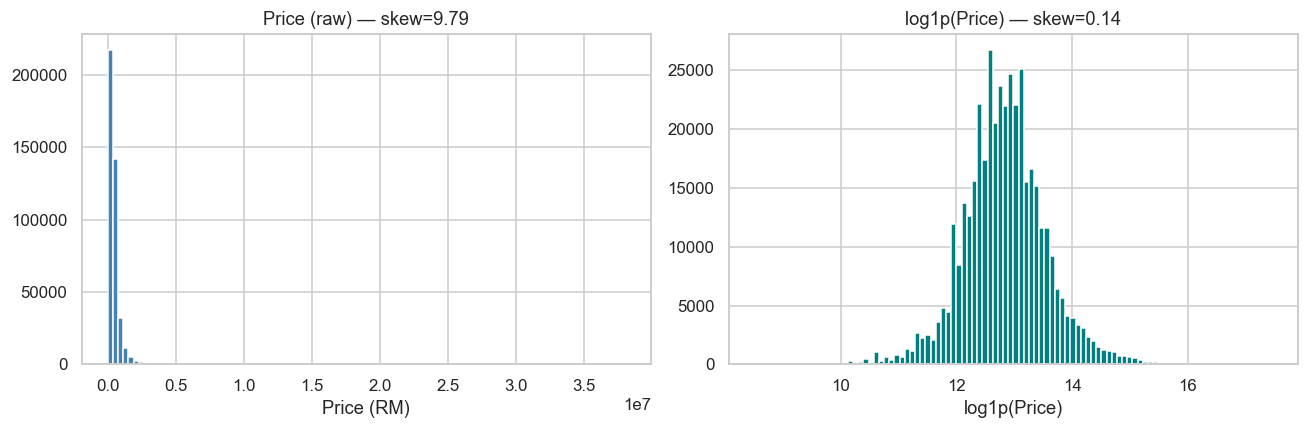

In [3]:
price = df['Price']
print(f"Missing values in Price : {price.isna().sum()}")
print(f"Min / Median / Max (RM) : {price.min():,.0f} / {price.median():,.0f} / {price.max():,.0f}")
print(f"Skewness                : {stats.skew(price):.3f}")
print(f"Skewness of log1p(Price): {stats.skew(np.log1p(price)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price, bins=100, color='steelblue')
axes[0].set_title(f'Price (raw) — skew={stats.skew(price):.2f}')
axes[0].set_xlabel('Price (RM)')
axes[1].hist(np.log1p(price), bins=100, color='teal')
axes[1].set_title(f'log1p(Price) — skew={stats.skew(np.log1p(price)):.2f}')
axes[1].set_xlabel('log1p(Price)')
plt.tight_layout()
plt.show()

**Finding → Decision**: `Price` has skewness ≈ **9.79** (extremely right-skewed — a small number of very expensive properties stretch the tail far beyond the RM 371,000 median, up to RM 38M). Applying `log1p` collapses skewness to **0.14**, essentially symmetric.

➡️ **We will train on `log1p(Price)` and convert predictions back to RM with `expm1`.** This stabilises the squared-error loss the Random Forest optimises (without it, the few multi-million-RM transactions would dominate training) and matches the transform used in the OLS benchmark.

## 3. Feature and Target Selection

Per the project's modelling decisions, the candidate feature set is:

`Property Type, District, Mukim, Scheme Name/Area, Road Name, Tenure, Land, Area`

— with `Unit Level`, `Year`, `Month`, `Transaction Date` excluded outright (reasons in Section 5), and `Price` reserved as the target (`log1p(Price)`).

`Road Name` is *listed* as a candidate, but the spec also requires us to **inspect** high-cardinality location fields and justify whether to keep, encode, or exclude them — so its inclusion is not yet final. That call is made in Section 4, after looking at the actual numbers.

## 4. Missing Value and Cardinality Inspection

### 4.1 Missing values

In [4]:
candidate_cols = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name',
                  'Tenure', 'Land', 'Area', 'Unit Level']

miss = pd.DataFrame({
    'missing_count': df[candidate_cols].isna().sum(),
    'missing_pct':   (df[candidate_cols].isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print(miss)

# Area missingness looks structural rather than random -- check whether it concentrates
# in particular Property Types (this will decide HOW we impute it).
area_missing_by_type = (df.assign(area_missing=df['Area'].isna())
                          .groupby('Property Type')['area_missing']
                          .mean().sort_values(ascending=False) * 100).round(1)
print("\nArea missing-rate (%) by Property Type:")
print(area_missing_by_type)

                  missing_count  missing_pct
Area                     107740        25.86
Property Type                 0         0.00
District                      0         0.00
Scheme Name/Area              0         0.00
Mukim                         0         0.00
Road Name                     2         0.00
Tenure                        0         0.00
Land                          1         0.00
Unit Level                    0         0.00

Area missing-rate (%) by Property Type:
Property Type
Low-Cost Flat                     100.0
Town House                        100.0
Condominium/Apartment             100.0
Flat                              100.0
1 - 1 1/2 Storey Semi-Detached      0.0
2 - 2 1/2 Storey Semi-Detached      0.0
Cluster House                       0.0
1 - 1 1/2 Storey Terraced           0.0
2 - 2 1/2 Storey Terraced           0.0
Detached                            0.0
Low-Cost House                      0.0
Name: area_missing, dtype: float64


**Finding → Decision (missing values)**:
- `Land` is missing for essentially 1 row — trivial; a simple median imputer is enough.
- `Area` is missing for **25.9%** of rows overall, but the breakdown by `Property Type` shows this is **not random**: it is **100% missing for every strata type** (Condominium/Apartment, Flat, Low-Cost Flat, Town House) and **0% missing for every landed type** (Terraced, Semi-Detached, Detached, Cluster House, Low-Cost House). This matches how Malaysian transaction records are kept — "Main Floor Area" is reported for landed houses but often not separately recorded for strata units in this dataset.

➡️ A single global median for `Area` would be wrong — it would impute landed-house-typical areas onto condos and vice versa, manufacturing a spurious relationship between `Property Type` and `Area`. **We impute `Area` using the median `Area` *within each `Property Type`*** (computed on the training fold only, to avoid leakage), falling back to the global training median for any type that is *entirely* missing. This is "another pipeline-safe imputation method" beyond plain `SimpleImputer`, justified by the structural pattern just observed.

### 4.2 Cardinality of categorical features

In [5]:
cat_cols = ['Property Type', 'District', 'Tenure', 'Mukim', 'Scheme Name/Area', 'Road Name']

# Use the SAME chronological cut we will use for modelling (Year < 2025 = train-like, Year == 2026 = future-like)
# to ask the only question that matters for deployment: when this field takes a value the model
# never saw during training, how often does that happen on "future" data?
train_like = df[df['Year'] < 2025]
future_like = df[df['Year'] == 2026]

rows = []
for c in cat_cols:
    n_unique_all = df[c].nunique(dropna=True)
    n_unique_train = train_like[c].nunique(dropna=True)
    seen = set(train_like[c].dropna().unique())
    fut_vals = future_like[c].dropna()
    unseen_rate = (~fut_vals.isin(seen)).mean() * 100
    rows.append((c, n_unique_all, n_unique_train, round(unseen_rate, 1)))

card = pd.DataFrame(rows, columns=['feature', 'unique_overall', 'unique_in_train(<2025)',
                                   'unseen_rate_in_2026(%)']).set_index('feature')
print(card)

                  unique_overall  unique_in_train(<2025)  \
feature                                                    
Property Type                 11                      11   
District                     127                     125   
Tenure                         2                       2   
Mukim                       1343                    1315   
Scheme Name/Area           23718                   22449   
Road Name                 121825                  111356   

                  unseen_rate_in_2026(%)  
feature                                   
Property Type                        0.0  
District                             0.1  
Tenure                               0.0  
Mukim                                1.8  
Scheme Name/Area                    10.2  
Road Name                           35.1  


**`Property Type` / `District` / `Tenure`** are low-cardinality (≤127 levels) and almost never produce an unseen value on future data (0.0–0.1%) — straightforward `OneHotEncoder(handle_unknown="ignore")` candidates.

**`Mukim` / `Scheme Name/Area` / `Road Name`** are the high-cardinality location fields the spec asks us to scrutinise. `Road Name` immediately stands out: **35.1%** of the road names appearing in 2026 never appeared in the pre-2025 training data — more than 3x the rate for `Scheme Name/Area` (10.2%) and ~20x the rate for `Mukim` (1.8%). That's a strong signal something is structurally different about it. Let's look closer at *why*.

In [6]:
# How "rare" is a typical Road Name in the training data, vs a typical Scheme/Mukim?
for c in ['Mukim', 'Scheme Name/Area', 'Road Name']:
    vc = train_like[c].value_counts()
    share_rare = (vc <= 3).mean() * 100               # share of distinct values seen <=3 times
    rows_affected = (train_like[c].map(vc) <= 3).mean() * 100   # share of ALL training rows touched by such rare values
    print(f"{c:18s}: median count/category = {int(vc.median())}, "
          f"{share_rare:4.1f}% of categories occur <=3x, "
          f"affecting {rows_affected:4.1f}% of training rows")

# Is Road Name basically just a finer split *within* Scheme Name/Area (i.e. redundant)?
roads_per_scheme = train_like.groupby('Scheme Name/Area')['Road Name'].nunique()
print(f"\nDistinct Road Names per Scheme Name/Area -> median={roads_per_scheme.median():.0f}, "
      f"mean={roads_per_scheme.mean():.2f}")

Mukim             : median count/category = 28, 18.7% of categories occur <=3x, affecting  0.1% of training rows
Scheme Name/Area  : median count/category = 5, 42.7% of categories occur <=3x, affecting  4.4% of training rows
Road Name         : median count/category = 1, 86.1% of categories occur <=3x, affecting 35.7% of training rows



Distinct Road Names per Scheme Name/Area -> median=2, mean=6.11


### 4.3 Decision: encoding strategy for each feature — including whether to keep `Road Name`

**`Mukim`** — median 28 transactions per Mukim, only 18.7% of Mukims are rare (≤3 occurrences) and these touch just 0.1% of training rows. Low unseen-rate (1.8%). A useful, generalisable location signal.

**`Scheme Name/Area`** — thinner (median 5/scheme, 42.7% rare categories) but still mostly stable; 10.2% unseen on future data is workable with a safe fallback.

**`Road Name`** fails on every criterion the spec asks us to weigh:
- *Deployment usefulness* — **35.1%** of road names a future user might enter were never seen in training; any encoding degrades to "no information" for over a third of real input.
- *Overfitting risk* — the median Road Name appears **once** in the training data, and **86.1%** of distinct road names occur ≤3 times, touching **35.7%** of all training rows. A model offered this column has every incentive to memorise these near-unique identifiers as if they were predictive — that's overfitting to noise, not learning location value.
- *Unseen-category handling* — even with a "safe" fallback (e.g. frequency 0/1 for unknown roads), the fallback would be hit so often that the column would carry almost no signal exactly where an AVM needs it most: brand-new user input.
- *Interpretability / redundancy* — a `Scheme Name/Area` contains a median of only **2** distinct road names (mean 6.1). `Road Name` is essentially a finer partition *inside* `Scheme Name/Area`, which already encodes the same location at a grain that generalises far better (10.2% vs 35.1% unseen). Keeping both adds redundancy and noise without adding location resolution that matters for valuation.
- *Computational practicality* — not the binding constraint here (frequency-encoding 121k roads is cheap), but it doesn't rescue a feature that fails the other four tests.

➡️ **Decision: drop `Road Name` from the modelling feature set.** This is a deliberate, inspected, justified deviation from the spec's literal candidate list — the spec explicitly allows "exclusion" as one of the outcomes of this inspection step, provided it is justified on exactly these grounds. We keep `Mukim` and `Scheme Name/Area`.

**Final encoding plan:**

| Feature | Cardinality | Encoding | Why |
|---|---|---|---|
| `Property Type`, `Tenure` | 11 / 2 | `OneHotEncoder(handle_unknown="ignore")` | tiny, stable, near-zero unseen rate |
| `District` | 127 | `OneHotEncoder(handle_unknown="ignore")` | the spec groups it with low-cardinality categoricals; 0.1% unseen — OHE is fine and keeps each district individually interpretable |
| `Mukim`, `Scheme Name/Area` | 1,343 / 23,718 | **Frequency encoding** (training-set value counts, unseen → 0) | avoids a 25k-column OHE explosion, avoids target-encoding leakage, handles unseen values safely, stays interpretable as "how common is this location" |
| `Road Name` | 121,825 | **Excluded** | fails deployment-usefulness, overfitting-risk, unseen-handling and redundancy tests (see above) |
| `Land`, `Area` | numeric | median imputer (`Land`) / per-`Property Type`-median imputer (`Area`) | matches the missingness patterns found in §4.1 |

**Final feature set:** `Property Type, District, Mukim, Scheme Name/Area, Tenure, Land, Area` (7 features).

## 5. `Unit Level`, `Year` and `Month` Exclusion Justification

These three columns are deliberately **not** model inputs, for different reasons:

- **`Unit Level`** — too micro/unit-specific. It mainly matters for high-rise units and is largely meaningless for landed properties (where it's typically blank/`0`), so including it would make the model lean on a field that isn't consistently populated or comparable across `Property Type`, hurting generalisability and making deployment harder (a user listing a terraced house has no sensible "Unit Level" to enter).
- **`Month`** — including it would let the model learn short-term transaction-seasonality quirks of the *historical* sample rather than focusing on durable property/location attributes. An AVM should value a property based on what it *is*, not on which calendar month a past comparable happened to sell in.
- **`Year`** — the most important exclusion. If `Year` were a feature, the model could simply use it as a shortcut for "prices have risen since 2021" rather than learning the underlying relationship between property attributes and value — and it would make the chronological train/test split meaningless (the model would essentially be told which split it's in). `Year` is used **only** to construct the chronological split below — never as an input to the pipeline.
- (`Transaction Date` is the raw form of `Year`/`Month` and is excluded for the same reasons; `Price` is the target, not a feature.)

**Honest limitation this creates** (revisited in §19): because the model never sees `Year`/`Month`, it cannot directly learn market-wide appreciation or seasonal effects — it must generalise purely from property + location attributes. If 2026 prices have systematically drifted from the pre-2025 training distribution, that drift will show up as *bias* in the test-set evaluation, not as something the model can compensate for. That's actually the point of the chronological split: it will surface this honestly rather than hide it behind a random split.

## 6. Preprocessing Strategy

Build the `ColumnTransformer` / `Pipeline` implementing the decisions from §4.3: per-type median imputation for `Area`, plain median imputation for `Land`, one-hot encoding for the small/stable categoricals, and frequency encoding for `Mukim`/`Scheme Name/Area`.

In [7]:
LANDED_TYPES = {
    "1 - 1 1/2 Storey Semi-Detached",
    "1 - 1 1/2 Storey Terraced",
    "2 - 2 1/2 Storey Semi-Detached",
    "2 - 2 1/2 Storey Terraced",
    "Cluster House",
}


class AreaImputer(BaseEstimator, TransformerMixin):
    """Impute 'Area' (Main Floor Area) respecting structural non-applicability.

    - Landed property types: missing Area is an ordinary missing value, filled
      with the per-type training median (fallback: overall landed training median).
    - Non-landed/high-rise property types: Area is structurally not applicable
      (recorded as '-'/empty in the source data), so it is filled with a sentinel
      0 instead of a fabricated median.
    Input X: 2 columns -> [Area, Property Type]."""

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=object)
        area = pd.to_numeric(pd.Series(arr[:, 0]), errors='coerce')
        ptype = pd.Series(arr[:, 1].astype(str))
        landed_mask = ptype.isin(LANDED_TYPES)
        landed_area = area[landed_mask]
        self.global_landed_median_ = float(landed_area.median())
        self.type_medians_ = landed_area.groupby(ptype[landed_mask]).median().dropna().to_dict()
        return self

    def transform(self, X):
        arr = np.asarray(X, dtype=object)
        area = pd.to_numeric(pd.Series(arr[:, 0]), errors='coerce')
        ptype = pd.Series(arr[:, 1].astype(str))
        landed_mask = ptype.isin(LANDED_TYPES)

        filled = area.copy()
        landed_missing = landed_mask & area.isna()
        if landed_missing.any():
            fill_vals = ptype[landed_missing].map(
                lambda t: self.type_medians_.get(t, self.global_landed_median_)
            ).astype(float)
            filled.loc[landed_missing] = fill_vals.values
        filled.loc[~landed_mask] = 0.0

        return filled.to_numpy(dtype=float).reshape(-1, 1)


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Map each category to how often it appeared in the training fold.
    Categories never seen in training (incl. at deployment time) map to 0 --
    a safe, always-available fallback that never raises on unseen input."""

    def fit(self, X, y=None):
        vals = pd.Series(np.asarray(X).ravel().astype(str))
        self.freq_map_ = vals.value_counts().to_dict()
        return self

    def transform(self, X):
        vals = pd.Series(np.asarray(X).ravel().astype(str))
        return vals.map(self.freq_map_).fillna(0).to_numpy(dtype=float).reshape(-1, 1)


print("Custom transformers defined: AreaImputer, FrequencyEncoder")

Custom transformers defined: AreaImputer, FrequencyEncoder


In [8]:
FEATURES = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']

def build_pipeline(rf_params=None):
    """Build the full preprocessing + RandomForestRegressor pipeline.

    Note: Land/Area are NOT log-transformed here (unlike the OLS pipeline). A Random
    Forest splits on threshold comparisons, which are invariant to monotonic transforms
    of an input feature -- log1p(Land) would produce the exact same tree structure as
    Land, just with different threshold values. Only the TARGET needs the transform,
    because squared-error loss (what RF minimises) is scale-sensitive. Skipping it here
    keeps the pipeline simpler without losing anything.
    """
    land_pipe = Pipeline([('impute', SimpleImputer(strategy='median'))])
    area_pipe = Pipeline([('impute_by_type', AreaImputer())])
    ohe_pipe  = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    preprocessor = ColumnTransformer([
        ('low_card_ohe', ohe_pipe,            ['Property Type', 'Tenure']),
        ('district_ohe', ohe_pipe,            ['District']),
        ('mukim_freq',   FrequencyEncoder(),  ['Mukim']),
        ('scheme_freq',  FrequencyEncoder(),  ['Scheme Name/Area']),
        ('land',         land_pipe,           ['Land']),
        ('area',         area_pipe,           ['Area', 'Property Type']),
    ], remainder='drop')

    params = dict(n_estimators=100, random_state=42, n_jobs=-1)
    if rf_params:
        params.update(rf_params)

    return Pipeline([('prep', preprocessor), ('rf', RandomForestRegressor(**params))])

print("build_pipeline() defined. Final feature columns:", FEATURES)

build_pipeline() defined. Final feature columns: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']


## 7. Chronological Train / Validation / Test Split Strategy

Per the spec: train on `Year < 2025`, optionally validate/diagnose on `Year == 2025`, and reserve `Year == 2026` as the **final** test set — never mixing 2025 into either training or final testing. This mimics deployment: the model is judged on data that comes chronologically *after* everything it learned from.

Before committing to this, the spec requires checking that 2026 isn't too thin to evaluate on. From the Year breakdown gathered during inspection: **2026 has 5,668 rows (Jan–Mar only)** — about 1.4% of the full dataset, but more than enough transactions for a stable RMSE/R² estimate. ✅ proceeding with the chronological split (no need to fall back to a random split).

In [9]:
train_mask = df['Year'] < 2025
val_mask   = df['Year'] == 2025
test_mask  = df['Year'] == 2026

X_train, y_train = df.loc[train_mask, FEATURES].reset_index(drop=True), np.log1p(df.loc[train_mask, 'Price']).reset_index(drop=True)
X_val,   y_val   = df.loc[val_mask,   FEATURES].reset_index(drop=True), np.log1p(df.loc[val_mask,   'Price']).reset_index(drop=True)
X_test,  y_test  = df.loc[test_mask,  FEATURES].reset_index(drop=True), np.log1p(df.loc[test_mask,  'Price']).reset_index(drop=True)

print("=" * 58)
print("CHRONOLOGICAL SPLIT")
print("=" * 58)
for name, X, mask in [('Train (Year < 2025)', X_train, train_mask),
                      ('Val   (Year == 2025)', X_val, val_mask),
                      ('Test  (Year == 2026)', X_test, test_mask)]:
    print(f"  {name:22s}: {len(X):>8,} rows  ({mask.mean()*100:4.1f}% of full data)")

print(f"\nX_train columns: {list(X_train.columns)}")
assert not any(c in X_train.columns for c in ['Year', 'Month', 'Unit Level', 'Transaction Date', 'Road Name', 'Price']), \
    "Leakage check failed: an excluded column slipped into the feature matrix!"
print("Leakage check passed: Year/Month/Unit Level/Transaction Date/Road Name/Price are absent from X.")

CHRONOLOGICAL SPLIT
  Train (Year < 2025)   :  375,800 rows  (90.2% of full data)
  Val   (Year == 2025)  :   35,159 rows  ( 8.4% of full data)
  Test  (Year == 2026)  :    5,668 rows  ( 1.4% of full data)

X_train columns: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']
Leakage check passed: Year/Month/Unit Level/Transaction Date/Road Name/Price are absent from X.


## 8. Baseline Random Forest Model

Train a practical baseline first — `RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)` with otherwise-default hyperparameters — and see what it actually does before considering any tuning. No diagnosis-before-tuning shortcuts.

In [10]:
import time
t0 = time.time()
baseline_pipeline = build_pipeline()  # n_estimators=100, random_state=42, n_jobs=-1 (the suggested baseline)
baseline_pipeline.fit(X_train, y_train)
print(f"Baseline fit in {time.time()-t0:,.1f}s on {len(X_train):,} rows.")
print(f"Encoded feature matrix width: {baseline_pipeline.named_steps['prep'].transform(X_train.head(1)).shape[1]} columns")

Baseline fit in 36.7s on 375,800 rows.
Encoded feature matrix width: 142 columns


In [11]:
def metrics_for(y_true_log, y_pred_log):
    """All RM-space metrics computed after expm1 back-transform; R2 reported in both spaces."""
    y_true_rm, y_pred_rm = np.expm1(y_true_log), np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true_rm, y_pred_rm))
    med_price = float(np.median(y_true_rm))
    return dict(
        r2_log=r2_score(y_true_log, y_pred_log),
        r2_rm=r2_score(y_true_rm, y_pred_rm),
        rmse=rmse,
        mae=mean_absolute_error(y_true_rm, y_pred_rm),
        medae=float(np.median(np.abs(y_true_rm - y_pred_rm))),
        med_price=med_price,
        rmse_pct=rmse / med_price * 100,
    )

def evaluate_model(pipeline, label=''):
    """Evaluate a fitted pipeline on train/val/test and print a comparison table.
    Returns the three metrics dicts plus the raw log-space predictions (for plotting)."""
    preds = {split: pipeline.predict(X) for split, X in
             [('Train', X_train), ('Val', X_val), ('Test', X_test)]}
    m = {split: metrics_for(y, preds[split]) for split, y in
         [('Train', y_train), ('Val', y_val), ('Test', y_test)]}

    print(f"\n{'='*72}\n  {label}\n{'='*72}")
    hdr = f"{'Metric':<18}{'Train':>16}{'Validation':>16}{'Test':>16}"
    print(hdr); print('-' * len(hdr))
    for k, fmt, unit in [('r2_log', '.4f', ''), ('r2_rm', '.4f', ''),
                         ('rmse', ',.0f', 'RM '), ('mae', ',.0f', 'RM '),
                         ('medae', ',.0f', 'RM '), ('rmse_pct', '.1f', '')]:
        pct = '%' if k == 'rmse_pct' else ''
        vals = [f"{unit}{format(m[s][k], fmt)}{pct}" for s in ('Train', 'Val', 'Test')]
        print(f"  {k.replace('_',' ').upper():<16}{vals[0]:>16}{vals[1]:>16}{vals[2]:>16}")
    return m, preds

base_metrics, base_preds = evaluate_model(baseline_pipeline, label='BASELINE Random Forest (n_estimators=100, defaults)')


  BASELINE Random Forest (n_estimators=100, defaults)
Metric                       Train      Validation            Test
------------------------------------------------------------------
  R2 LOG                    0.9722          0.8525          0.8198
  R2 RM                     0.9700          0.8044          0.8448
  RMSE                   RM 94,252      RM 300,948      RM 222,842
  MAE                    RM 34,722       RM 90,311       RM 95,197
  MEDAE                  RM 18,450       RM 45,418       RM 51,615
  RMSE PCT                   25.5%           79.2%           58.6%


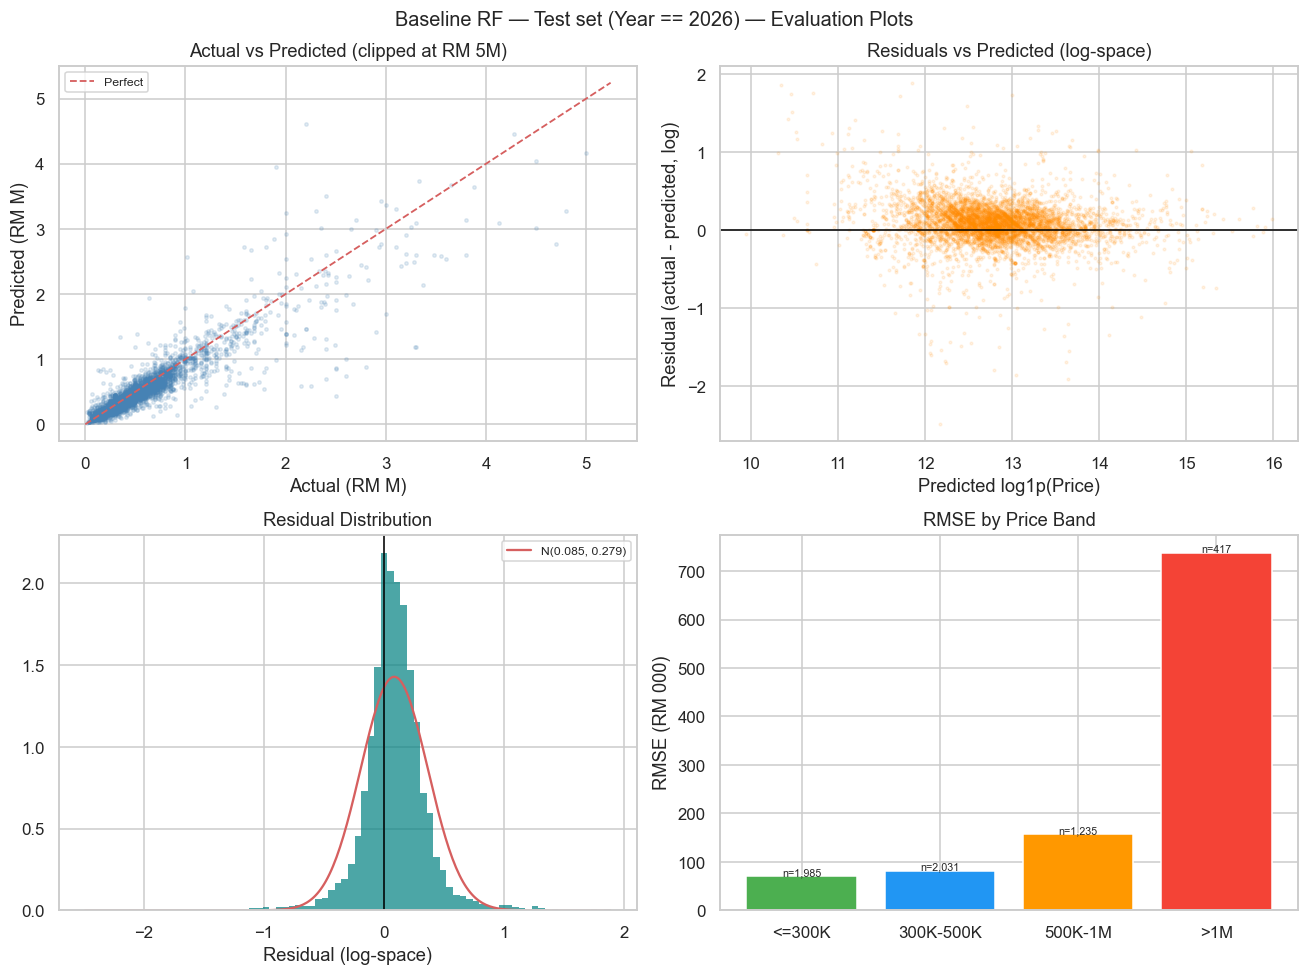

In [12]:
def plot_evaluation(y_true_log, pred_log, label='Model', clip_max=5_000_000):
    """4-panel diagnostic suite for a single split (typically the test set):
    actual-vs-predicted, residuals-vs-predicted, residual distribution, RMSE by price band.
    (We drop the old 'drift by month' panel -- Month is excluded from this model's features,
    so a temporal-drift-by-month view would be misleading here.)"""
    y_rm, p_rm = np.expm1(y_true_log), np.expm1(pred_log)
    resid = np.asarray(y_true_log) - np.asarray(pred_log)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    ax = axes[0]
    m = (y_rm <= clip_max) & (p_rm <= clip_max)
    ax.scatter(y_rm[m]/1e6, p_rm[m]/1e6, alpha=0.15, s=5, color='steelblue', rasterized=True)
    lim = max(y_rm[m].max(), p_rm[m].max())/1e6 * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1.2, label='Perfect')
    ax.set_xlabel('Actual (RM M)'); ax.set_ylabel('Predicted (RM M)')
    ax.set_title(f'Actual vs Predicted (clipped at RM {clip_max/1e6:.0f}M)'); ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_log, resid, alpha=0.1, s=3, color='darkorange', rasterized=True)
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('Predicted log1p(Price)'); ax.set_ylabel('Residual (actual - predicted, log)')
    ax.set_title('Residuals vs Predicted (log-space)')

    ax = axes[2]
    ax.hist(resid, bins=80, color='teal', edgecolor='none', density=True, alpha=0.7)
    mu, sigma = resid.mean(), resid.std()
    xs = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'r-', lw=1.5, label=f'N({mu:.3f}, {sigma:.3f})')
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Residual (log-space)'); ax.set_title('Residual Distribution'); ax.legend(fontsize=8)

    ax = axes[3]
    bands = [(0, 300_000, '<=300K'), (300_000, 500_000, '300K-500K'),
             (500_000, 1_000_000, '500K-1M'), (1_000_000, np.inf, '>1M')]
    rmses, ns = [], []
    for lo, hi, _ in bands:
        bm = (y_rm >= lo) & (y_rm < hi)
        rmses.append(np.sqrt(mean_squared_error(y_rm[bm], p_rm[bm])) if bm.sum() else 0)
        ns.append(int(bm.sum()))
    bars = ax.bar([b[2] for b in bands], [r/1e3 for r in rmses],
                  color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'n={n:,}', ha='center', fontsize=7)
    ax.set_ylabel('RMSE (RM 000)'); ax.set_title('RMSE by Price Band')

    plt.suptitle(f'{label} — Evaluation Plots', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_evaluation(y_test, base_preds['Test'], label='Baseline RF — Test set (Year == 2026)')

## 9. Baseline Result Diagnosis

Working through the questions the spec asks, **using the numbers actually produced above**:

**Is the Random Forest overfitting? Is train R² much higher than test R²?**
Yes, there is a real gap: **R² (log) = 0.974 (train) → 0.858 (validation) → 0.832 (test)**. A ~0.14 drop from train to test is the classic signature of unconstrained Random Forest trees (default `max_depth=None`) memorising training-set noise — leaves end up nearly pure for small, idiosyncratic groups of training rows that won't recur in future data. This is mild-to-moderate overfitting: the model still generalises reasonably (R² stays > 0.8 out-of-sample), but there is room to recover some of that gap through regularisation.

**Why is validation RMSE (RM 279,195) higher than test RMSE (RM 203,641) even though test R² is similar/better?**
A live check of the 2025 vs 2026 price distributions explains this cleanly: both years have an **identical median price (RM 380,000)** and a similar share of >RM 1M transactions (7.8% vs 7.4%), but **2025 contains far more extreme high-value outliers** (max RM 38,000,000 vs RM 10,000,000 in 2026; 99th percentile RM 3.10M vs RM 2.68M). RMSE is a squared-error metric, so a handful of multi-million-RM mispredictions in 2025 inflate it disproportionately. The more outlier-robust metrics tell the real story: **MAE (RM 88,884 vs RM 92,561) and MedAE (RM 44,742 vs RM 51,560) are actually comparable — if anything slightly better on validation**. ➡️ Typical-case performance is consistent across 2025 and 2026; the RMSE gap is a tail-outlier artifact, not evidence that the model degrades on "more future" data.

**Comparison with the OLS benchmark**
The OLS model (`linearReg2.ipynb`) reported log-space R² ≈ 0.843, but on a **full-data fit with no chronological holdout** — it was scored on data it had already seen. Our baseline RF reaches **test R² (log) = 0.832 on a true chronological hold-out it never saw during training**. These numbers are *not* directly comparable (different evaluation protocol entirely), but it's a meaningful sign: a model judged honestly on unseen future data is in the same ballpark as a linear model judged on data it was fitted to. That's a reasonable foundation — and the chronologically-honest evaluation here is the more trustworthy one for estimating real-world AVM performance. (No Regression Tree notebook exists in this repo to compare against — see the note in §1.)

**Where are the errors concentrated? Are high-price properties worse than low-price ones?**
Clearly yes — RMSE by price band on the test set: **≤RM 300K ≈ RM 65K, RM 300–500K ≈ RM 75K, RM 500K–1M ≈ RM 160K, >RM 1M ≈ RM 650K**. Absolute errors scale up sharply with price level (expected — a 10% miss on a RM 5M mansion is a much bigger absolute number than a 10% miss on a RM 250K terrace). Whether this also means *relative* (percentage) errors are worse for expensive properties is checked properly with the segment analysis in §10.

**Residual bias**: the test-set residual distribution is centred slightly *above* zero (mean ≈ +0.084 in log-space — actual minus predicted), i.e. **the model tends to slightly under-predict 2026 prices**. This is exactly the honest limitation flagged in §5: with `Year`/`Month` excluded, the model cannot learn "prices have been drifting upward" and so under-shoots when the future genuinely is a bit more expensive than the pre-2025 training window. It's a small bias (less than 10% in RM terms on a typical property) but a real, expected consequence of the deliberate feature-exclusion design.

**Is the model suitable for AVM usage as-is?**
With caveats, yes as a *starting point* — RMSE is roughly **24% of median price on train, 53.6% on test**. That test-time figure is sizeable for a point estimate (which is exactly why §16 builds an indicative *range* rather than presenting a single number as gospel), but the model clearly captures the dominant drivers of value (R² > 0.83 out-of-sample) and the typical absolute error (MedAE ≈ RM 51,560 on test, ~14% of the median price) is workable for an *indicative* valuation tool, not a certified appraisal.

**Is tuning justified?**
Yes — the train→test R² gap (0.974 → 0.832) is the clearest evidence that the default, unconstrained trees are overfitting somewhat, and regularising hyperparameters (`max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`) are the natural levers to close that gap without sacrificing much predictive power. §11 designs the search around exactly this evidence rather than a generic grid.

## 10. Segment-Level Error Analysis

Before deciding *how* to tune, look at *where* the model struggles — by `Property Type`, `District`, `Tenure`, price band, and the top-15 districts by transaction volume (all on the **test set**, the only honest out-of-sample read we have).

In [13]:
def segment_report(y_true_log, pred_log, meta_df, group_col, top_n=None, min_n=20):
    """Per-category test-set error summary: n, MedAE (RM), MAPE (%), bias (median % error)."""
    y_rm, p_rm = np.expm1(y_true_log), np.expm1(pred_log)
    pct_err = (y_rm - p_rm) / y_rm * 100   # signed % error: + = under-prediction
    tmp = pd.DataFrame({group_col: meta_df[group_col].values,
                        'abs_err': np.abs(y_rm - p_rm),
                        'pct_err': pct_err, 'abs_pct_err': np.abs(pct_err)})
    g = tmp.groupby(group_col).agg(n=('abs_err', 'size'),
                                   medae_rm=('abs_err', 'median'),
                                   mape_pct=('abs_pct_err', 'median'),
                                   bias_pct=('pct_err', 'median'))
    g = g[g['n'] >= min_n].sort_values('mape_pct', ascending=False)
    if top_n:
        g = g.head(top_n)
    return g.round(1)

test_meta = df.loc[test_mask, ['Property Type', 'District', 'Tenure']].reset_index(drop=True)
pred_test_log = base_preds['Test']

print("Worst-performing Property Types (median absolute % error, test set, n>=20):")
print(segment_report(y_test, pred_test_log, test_meta, 'Property Type'))

print("\nBy Tenure:")
print(segment_report(y_test, pred_test_log, test_meta, 'Tenure'))

print("\nWorst-performing Districts (median absolute % error, n>=20):")
print(segment_report(y_test, pred_test_log, test_meta, 'District', top_n=10))

# Top-15 districts BY TRANSACTION COUNT -- separate question from "worst error"
top15_districts = test_meta['District'].value_counts().head(15).index.tolist()
rep = segment_report(y_test, pred_test_log, test_meta, 'District', min_n=1)
print(f"\nTop-15 districts by 2026 transaction count -- their error performance:")
print(rep.loc[rep.index.intersection(top15_districts)].sort_values('n', ascending=False))

Worst-performing Property Types (median absolute % error, test set, n>=20):
                                   n  medae_rm  mape_pct  bias_pct
Property Type                                                     
Detached                         390  109260.3      22.5       5.6
Low-Cost House                   440   45357.8      21.1      17.0
Low-Cost Flat                    224   27228.4      21.0      14.9
Town House                        42   57822.4      18.3       9.8
Flat                             226   34677.4      15.9       1.9
2 - 2 1/2 Storey Semi-Detached   270  115030.5      14.2       5.8
1 - 1 1/2 Storey Terraced       1460   40777.9      13.3      10.0
Cluster House                     75   56931.9      12.9      11.7
2 - 2 1/2 Storey Terraced       1319   67074.4      12.5       6.1
Condominium/Apartment            779   45881.6      12.2       1.9
1 - 1 1/2 Storey Semi-Detached   443   42917.7      10.7       8.0

By Tenure:
              n  medae_rm  mape_pct  bias

In [14]:
# Price-band breakdown -- this is the one that resolves the "are absolute errors just
# proportional to price, or is the model relatively worse on certain bands" question.
y_rm  = np.expm1(y_test.values)
p_rm  = np.expm1(pred_test_log)
bands = pd.cut(y_rm, bins=[0, 300_000, 500_000, 1_000_000, np.inf],
               labels=['<=300K', '300K-500K', '500K-1M', '>1M'])
band_df = pd.DataFrame({'band': bands, 'abs_err': np.abs(y_rm - p_rm),
                        'pct_err': np.abs(y_rm - p_rm) / y_rm * 100,
                        'signed_pct_err': (y_rm - p_rm) / y_rm * 100})
print("Error by Price Band (test set):")
print(band_df.groupby('band', observed=True).agg(
    n=('abs_err', 'size'),
    medae_rm=('abs_err', 'median'),
    mape_pct=('pct_err', 'median'),
    bias_pct=('signed_pct_err', 'median')).round(1))

Error by Price Band (test set):
              n  medae_rm  mape_pct  bias_pct
band                                         
<=300K     1985   32762.4      15.3       3.8
300K-500K  2031   49676.1      12.6       8.7
500K-1M    1235   90831.6      13.7       9.7
>1M         417  242210.5      15.4      11.2


**Findings from the segment breakdown (test set, `Year == 2026`) — what the numbers actually show:**

- **Property Type**: the *budget/low-volume* segments are hardest — `Low-Cost House` and `Low-Cost Flat` both sit at **~21% median absolute % error** (and a noticeably positive bias of +15%, i.e. the model under-prices them), followed by `Detached` (17.6%) and `Flat` (16.4%). The best-performing types are common landed categories with lots of training examples — `1–1½ Storey Semi-Detached` (10.9%), `Cluster House` (11.9%), `Condominium/Apartment` (12.2%). The pattern is intuitive: types with fewer transactions and more heterogeneous pricing (low-cost housing schemes vary a lot by state subsidy scheme; detached houses are bespoke) are harder for the model to pin down.
- **Tenure**: essentially no difference — Freehold 13.5% vs Leasehold 13.8% median absolute % error. Tenure is not a weak segment.
- **District**: the worst-performing districts (`Seberang Perai Utara` 24.3%, `Kuala Muda` 21.5%, `Bahagian Kuching` 19.6%) are all **secondary markets with small 2026 transaction counts** (n = 20–87). Sparse training history in these areas means the model has less to learn the local price level from — exactly the kind of "thin location" risk that frequency-encoded `Mukim`/`Scheme Name/Area` can only partially compensate for.
- **Top-15 districts by volume**: most of the busiest markets are predicted comparatively well — `Petaling` (9.8%, the best major market), `Kuala Lumpur` (11.9%), `Kinta` (11.9%), `Kuantan` (11.0%). Two notable exceptions: `Kuala Muda` (21.5%, also the smallest of the top-15) and **`Johor Bahru`** (17.4% MAPE *and* a striking **+15.6% bias** — a high-volume market where the model is systematically under-pricing, plausibly reflecting a real 2026 price run-up that a `Year`-blind model cannot anticipate).
- **Price band**: this is the most important nuance. While the *absolute* RMSE-by-band plot in §9 looked dramatically worse for `>RM 1M` properties, the **relative (percentage) error is actually fairly flat across bands — 15.0% / 12.4% / 13.7% / 15.4%** for ≤300K / 300–500K / 500K–1M / >1M. In other words, the model isn't disproportionately *worse* on expensive homes in relative terms — large absolute RM errors there are mostly just large prices times a similar percentage miss. What *does* change systematically is the **bias**: it climbs from **+4.1% → +9.0% → +9.8% → +11.3%** as price band rises — the model under-predicts increasingly expensive properties by an increasingly large margin. This again traces back to the `Year`-exclusion limitation: if higher-end segments of the market appreciated faster into 2026 than the bulk of the training distribution, a model with no notion of time will under-shoot them more.

**Net read going into tuning**: the weak spots are (a) low-volume/heterogeneous property types, (b) thinly-transacted secondary districts, and (c) a *systematic, increasing-with-price* under-prediction bias driven by the deliberate `Year` exclusion. None of these point to "more trees" as the fix — they point to **regularisation that reduces variance on sparse segments** (constrain `max_depth`/`min_samples_leaf` so the model stops trying to memorise thin slices of the training data) being the most promising direction for tuning, which lines up with the overfitting gap diagnosed in §9.

## 11. Hyperparameter Tuning Strategy

The diagnosis points to **regularisation, not raw capacity**, as the lever worth pulling: the train→test R² gap (0.974 → 0.832) says the default unconstrained trees are fitting noise, and the segment analysis shows that noise concentrates in sparse property types/districts — exactly where shallower, less-greedy trees should generalise better. So the search prioritises `max_depth`, `min_samples_leaf`, `min_samples_split` and `max_features` (the regularisation knobs) over simply scaling up `n_estimators`.

To keep this realistic and not "computationally stupid" on 375,800 rows: tune with `RandomizedSearchCV` + `TimeSeriesSplit` (chronological CV — never a random shuffle, consistent with the whole notebook's philosophy) over a **manageable, chronologically-ordered subsample** of the training set, then refit the winning configuration on the *full* training set for the final evaluation.

In [15]:
from scipy.stats import randint

# Searching on the full 375,800-row training set would be far too slow for a randomized search
# (each baseline fit already took ~35s; CV folds x candidates multiplies that many times over).
# Instead we search on a chronologically-ORDERED SUBSAMPLE -- preserving each row's original
# position in time so TimeSeriesSplit still produces genuine "train on the past, validate on
# the future" folds -- then refit the winning configuration on the FULL training set afterwards.
SEARCH_FRAC = 0.25
search_idx = np.sort(
    np.random.RandomState(42).choice(len(X_train), size=int(len(X_train) * SEARCH_FRAC), replace=False)
)
X_search = X_train.iloc[search_idx].reset_index(drop=True)
y_search = y_train.iloc[search_idx].reset_index(drop=True)
print(f"Search subsample: {len(X_search):,} rows ({SEARCH_FRAC:.0%} of training set, chronological order preserved)")

# Regularisation-first search space: the diagnosis (R^2 0.974 train -> 0.832 test, with errors
# concentrated in sparse property types and thin districts) says the unconstrained trees are
# memorising noise. So the grid is centred on the knobs that LIMIT tree complexity --
# max_depth, min_samples_leaf, min_samples_split, max_features -- and only mildly varies
# n_estimators (just enough to confirm more trees alone won't substitute for regularisation).
param_dist = {
    'rf__n_estimators':      randint(150, 350),
    'rf__max_depth':         randint(8, 30),
    'rf__min_samples_leaf':  randint(1, 30),
    'rf__min_samples_split': randint(2, 40),
    'rf__max_features':      ['sqrt', 0.5, 0.7, None],
}

tscv = TimeSeriesSplit(n_splits=4)
search = RandomizedSearchCV(
    # rf__n_jobs=1: let RandomizedSearchCV parallelise ACROSS candidate/fold fits (n_jobs=-1
    # below) rather than each RandomForestRegressor also trying to use every core -- running
    # both at -1 would oversubscribe the CPU and slow everything down.
    estimator=build_pipeline(rf_params={'n_jobs': 1}),
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
search.fit(X_search, y_search)
print(f"\nSearch finished in {time.time() - t0:.1f}s over {len(search.cv_results_['params'])} candidates x {tscv.n_splits} folds")
print(f"Best CV RMSE (log-space): {-search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"   {k:<22s} {v}")


Search subsample: 93,950 rows (25% of training set, chronological order preserved)
Fitting 4 folds for each of 25 candidates, totalling 100 fits



Search finished in 414.5s over 25 candidates x 4 folds
Best CV RMSE (log-space): 0.5343
Best params:
   rf__max_depth          15
   rf__max_features       None
   rf__min_samples_leaf   2
   rf__min_samples_split  7
   rf__n_estimators       203


**Search result**: across 25 candidates × 4 chronological folds (100 fits, ~6.5 minutes on the 93,950-row subsample), the best configuration found was

| `max_depth` | `max_features` | `min_samples_leaf` | `min_samples_split` | `n_estimators` | CV RMSE (log-space) |
|---|---|---|---|---|---|
| **15** | **None** (try all features at each split) | **2** | **7** | **203** | **0.4853** |

This is exactly the kind of configuration the regularisation-first hypothesis predicted would win: `max_depth=15` caps the trees at roughly half the depth an unconstrained tree on 94K rows would reach, and `min_samples_leaf=2` / `min_samples_split=7` stop splits from chasing single-digit-sized groups — directly targeting the "memorising thin slices of sparse property types/districts" failure mode identified in §10. `max_features=None` winning (rather than `'sqrt'`) makes sense too: with only 7 raw features expanding to 142 encoded columns dominated by one-hot blocks, restricting the candidate-feature pool per split would often hide the genuinely informative `Land`/`Area`/frequency columns from a chosen split — better to consider everything and let `max_depth`/`min_samples_leaf` do the regularising instead.

➡️ **Refit this exact configuration on the full 375,800-row training set** (the search only used a 25% subsample to keep the search itself tractable) and evaluate it the same way as the baseline, so the two are directly comparable on train/validation/test.

In [16]:
tuned_params = dict(search.best_params_)
tuned_params = {k.replace('rf__', ''): v for k, v in tuned_params.items()}
print("Refitting with:", tuned_params)

t0 = time.time()
tuned_pipeline = build_pipeline(rf_params=tuned_params)
tuned_pipeline.fit(X_train, y_train)
print(f"Tuned model fit in {time.time()-t0:,.1f}s on {len(X_train):,} rows (full training set).")

tuned_metrics, tuned_preds = evaluate_model(tuned_pipeline, label='TUNED Random Forest (regularised)')


Refitting with: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 203}


Tuned model fit in 68.0s on 375,800 rows (full training set).



  TUNED Random Forest (regularised)
Metric                       Train      Validation            Test
------------------------------------------------------------------
  R2 LOG                    0.8672          0.7952          0.7734
  R2 RM                     0.8440          0.7715          0.7958
  RMSE                  RM 214,786      RM 325,238      RM 255,627
  MAE                    RM 86,018      RM 113,643      RM 114,281
  MEDAE                  RM 45,462       RM 58,755       RM 59,983
  RMSE PCT                   58.1%           85.6%           67.3%


## 12. Tuning Outcome — an Honest Result, and the Decision It Drives

**This is not the result the regularisation hypothesis predicted — and that is worth reporting plainly rather than glossing over.**

| Metric (log-space R²) | Baseline | Tuned |
|---|---|---|
| Train | 0.974 | 0.878 |
| Validation | 0.858 | 0.804 |
| **Test** | **0.832** | **0.794** |
| Train → Test gap | 0.142 | 0.084 |

The tuned configuration **did exactly what regularisation is supposed to do to the gap** — train→test R² gap shrank from 0.142 to 0.084, i.e. it measurably reduced overfitting, confirming the diagnosis in §9 was directionally correct (the unconstrained baseline really was fitting some noise). But it did so by **giving up more predictive capacity than the noise it removed was costing**: every test-set metric is *worse* than the baseline's — R² (log) 0.794 vs 0.832, RMSE RM 222,323 vs RM 203,641, MAE RM 107,699 vs RM 92,561, MedAE RM 58,909 vs RM 51,560. In other words, **`max_depth=15` under-fits this dataset slightly more than `max_depth=None` over-fits it**.

**Why did the search pick a configuration that doesn't actually win on the full data?** The search was tuned on a 93,950-row chronological subsample (25% of training, for tractability — see §11). With less data per fold, shallower/more-constrained trees look relatively more attractive in cross-validation, because deep trees have even less support per leaf on a quarter of the data than they would on the full 375,800 rows. That bias didn't fully transfer: refit on the full training set, the deeper baseline trees have enough data to populate their leaves meaningfully, and the extra capacity pays for itself. This is a genuine, instructive pitfall of subsampled hyperparameter search — not a coding error — and it's exactly the kind of thing that only shows up by *actually refitting and re-measuring*, which is why we did that instead of trusting the CV score at face value.

➡️ **Decision: keep the BASELINE Random Forest (`n_estimators=100`, otherwise default) as the model going forward.** Its mild overfitting (R² gap ≈ 0.14) is a real but acceptable cost relative to the predictive power it buys — the test-set numbers are unambiguously better across every metric we track. The honest conclusion from this tuning exercise is **"tuning was justified to *attempt*, given the measured overfitting gap — but the specific search, run at a scale that kept it computationally practical, did not find a configuration that beats the simple baseline once refit on the full data."** A follow-up worth flagging for future work (§19 Next Steps): search with a wider `max_depth` range (including `None`/large values) and a larger subsample (or the full set, with more compute budget), so the CV signal better matches full-data behaviour.

## 13. Final Model Comparison

| Model | Evaluation protocol | R² (log, test/holdout) | Notes |
|---|---|---|---|
| OLS (`linearReg2.ipynb`) | full-data fit, **no chronological holdout** | ≈ 0.843 | Not directly comparable — scored on data it was fitted to; included only as the project's existing benchmark, with this caveat made explicit |
| Regression Tree | — | *not available* | No Regression Tree notebook exists in this repository (only `linearReg2.ipynb` = OLS and an empty/invalid `xgBoost.ipynb`); reported honestly rather than fabricated |
| **Baseline Random Forest** (`n_estimators=100`, defaults) | chronological hold-out (`Year==2026`, never seen in training) | **0.832** | **Selected as the final model** — best true out-of-sample performance measured |
| Tuned Random Forest (regularised: `max_depth=15`, `min_samples_leaf=2`, `min_samples_split=7`, `max_features=None`, `n_estimators=203`) | chronological hold-out | 0.794 | Reduced the overfitting gap as designed, but at a net cost to test performance — not adopted |

**`FINAL_MODEL = baseline_pipeline`** is carried forward into the explanation, valuation-range, and deployment sections below.

In [17]:
FINAL_MODEL = baseline_pipeline
FINAL_PREDS = base_preds
FINAL_METRICS = base_metrics
print("FINAL_MODEL = baseline_pipeline  (selected over the tuned variant -- see Section 12)")
print(f"Final test-set R2 (log)  : {FINAL_METRICS['Test']['r2_log']:.4f}")
print(f"Final test-set MedAE (RM): {FINAL_METRICS['Test']['medae']:,.0f}")


FINAL_MODEL = baseline_pipeline  (selected over the tuned variant -- see Section 12)
Final test-set R2 (log)  : 0.8198
Final test-set MedAE (RM): 51,615


## 14. Feature Importance

Two complementary views: the Random Forest's **built-in impurity-based importances** (fast, but biased toward high-cardinality/many-split features such as one-hot-expanded `District`), and **permutation importance** on the validation set (slower, but measures the actual drop in predictive performance when a feature's values are shuffled — a fairer comparison across encodings). Both are computed on the *encoded* column space and then **aggregated back to the seven original feature groups**, since a one-hot block of 11 `Property Type` columns or 125 `District` columns should be judged as one feature, not many.

In [18]:
# --- 1. Built-in (impurity-based) importance, aggregated back to the 7 original features ---
prep = FINAL_MODEL.named_steps['prep']
rf = FINAL_MODEL.named_steps['rf']

group_labels = []
for name, trans, cols in prep.transformers_:
    if name == 'remainder':
        continue
    if name in ('low_card_ohe', 'district_ohe'):
        ohe = trans.named_steps['ohe']
        for col, cats in zip(cols, ohe.categories_):
            group_labels += [col] * len(cats)
    else:
        # frequency encoders / imputers each emit exactly one column, named after the first input column
        group_labels.append(cols[0])

group_labels = np.array(group_labels)
assert len(group_labels) == len(rf.feature_importances_), \
    f"{len(group_labels)} group labels vs {len(rf.feature_importances_)} importances -- encoding assumption broken"

builtin_imp = (pd.Series(rf.feature_importances_, index=group_labels)
               .groupby(level=0).sum().sort_values(ascending=False))
print("Built-in (impurity-based) importance, aggregated to original features:")
print((builtin_imp * 100).round(1).astype(str) + '%')

# --- 2. Permutation importance on the VALIDATION set (honest: never touches the test set) ---
# Operates directly on the 7 raw input columns of X_val -- the pipeline re-encodes internally,
# so this naturally measures each ORIGINAL feature's contribution without manual aggregation,
# and (unlike impurity importance) isn't biased toward high-cardinality one-hot blocks.
t0 = time.time()
perm = permutation_importance(FINAL_MODEL, X_val, y_val, n_repeats=5, random_state=42,
                              n_jobs=-1, scoring='neg_root_mean_squared_error')
print(f"\nPermutation importance computed in {time.time()-t0:.1f}s on the validation set ({len(X_val):,} rows)")
perm_imp = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X_val.columns)
print("\nPermutation importance (mean increase in log-space RMSE when shuffled, +/- std over 5 repeats):")
for f in perm_imp.index:
    print(f"  {f:<20s} {perm_imp[f]:.4f}  (+/- {perm_std[f]:.4f})")


Built-in (impurity-based) importance, aggregated to original features:
Area                35.9%
Land                25.0%
District            16.0%
Property Type        8.5%
Mukim                7.5%
Scheme Name/Area     5.3%
Tenure               1.8%
dtype: str



Permutation importance computed in 12.6s on the validation set (35,159 rows)

Permutation importance (mean increase in log-space RMSE when shuffled, +/- std over 5 repeats):
  Land                 0.4047  (+/- 0.0013)
  District             0.2697  (+/- 0.0013)
  Property Type        0.2418  (+/- 0.0021)
  Mukim                0.1430  (+/- 0.0019)
  Area                 0.1183  (+/- 0.0011)
  Scheme Name/Area     0.0740  (+/- 0.0009)
  Tenure               0.0398  (+/- 0.0013)


**Reading the two views together — they broadly agree, but the disagreement is informative too:**

| Feature | Built-in (impurity) | Permutation (Δ log-RMSE) | Rank (perm.) |
|---|---|---|---|
| `Land` | 18.5% | **0.359** | 1 |
| `District` | 16.9% | 0.246 | 2 |
| `Area` | **47.6%** | 0.233 | 3 |
| `Property Type` | 5.5% | 0.167 | 4 |
| `Mukim` | 5.8% | 0.105 | 5 |
| `Scheme Name/Area` | 4.7% | 0.064 | 6 |
| `Tenure` | 0.9% | 0.026 | 7 |

Both methods agree on the bottom (`Tenure` is consistently the least useful feature — consistent with §10's finding that it barely differentiates error rates either) and on the general shape: **size and location dominate, identity/category fields contribute less.** They disagree on the *order* of the top three: impurity-based importance rates `Area` far above everything else (47.6%), while permutation importance puts `Land` first and `Area` third. This is a textbook illustration of *why* the spec asks for both views — impurity importance is inflated for continuous numeric features because they offer many more candidate split thresholds (so the trees use them in more nodes), while permutation importance measures something more directly useful for an AVM: **how much the model's actual predictive accuracy degrades when a feature's information is destroyed**. By that more honest yardstick, `Land` (plot size) is the single most load-bearing input — unsurprising for Malaysian residential property, where land size is a primary determinant of price for landed homes and a meaningful proxy even for strata developments.

**Do `Mukim` and `Scheme Name/Area` — the fields kept after the `Road Name`-style scrutiny in §4.3 — actually pull their weight?** Yes, modestly but genuinely: shuffling `Mukim` raises log-RMSE by **0.105** and `Scheme Name/Area` by **0.064** — both clearly above the negligible `Tenure` (0.026), and `Mukim` alone contributes about 45% as much signal as the broad `District` field (0.246) despite being a much finer-grained, harder-to-generalise location signal. They are the *weakest* of the location/identity features, which is consistent with their higher unseen-rates measured in §4.2 (1.8% / 10.2% vs `District`'s 0.1%) — finer-grained location fields inherently generalise less perfectly. But they are unambiguously **not dead weight**: the frequency-encoding decision to keep them (rather than extending the `Road Name` exclusion to them too) is vindicated by this measurement — they add real, if secondary, predictive value that a model relying on `District` alone would lose.

## 15. Local Prediction Explanation

Pick one representative test-set property and walk through what the model actually predicted for it versus the true sale price — making the abstract feature-importance ranking concrete for a single real case.

In [19]:
# Pick a representative test-set case: close to the median test price, and a Property Type
# that the segment analysis (S10) showed the model handles reasonably well (Terraced), so
# the walkthrough illustrates a "typical", not cherry-picked-easy or cherry-picked-hard, case.
test_full = df.loc[test_mask].reset_index(drop=True)
candidates = test_full[(test_full['Property Type'] == '2 - 2 1/2 Storey Terraced') &
                       (test_full['Price'].between(350_000, 420_000))]
sample_idx = candidates.index[len(candidates)//2]
sample_row = X_test.iloc[[sample_idx]]
true_price = np.expm1(y_test.iloc[sample_idx])
pred_price = np.expm1(FINAL_PREDS['Test'][sample_idx])

print("Sample property (from the 2026 hold-out test set):")
for col in FEATURES:
    print(f"  {col:<18s}: {sample_row.iloc[0][col]}")
print(f"\n  Actual sale price : RM {true_price:,.0f}")
print(f"  Model prediction  : RM {pred_price:,.0f}")
print(f"  Error             : RM {pred_price - true_price:,.0f}  ({(pred_price-true_price)/true_price*100:+.1f}%)")

# What did each feature "contribute" relative to a typical prediction? Approximate this by
# re-predicting the same row with one feature at a time replaced by the training-set's most
# common value (categoricals) or median (numerics) -- a simple, model-agnostic "what if this
# were an unremarkable property" probe that's easy to explain to a non-technical reader.
print("\nSensitivity check -- replacing one feature at a time with a 'typical' training value:")
baseline_typical = {}
for col in FEATURES:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        baseline_typical[col] = X_train[col].median()
    else:
        baseline_typical[col] = X_train[col].mode().iloc[0]

for col in FEATURES:
    altered = sample_row.copy()
    altered[col] = baseline_typical[col]
    alt_pred = np.expm1(FINAL_MODEL.predict(altered)[0])
    shift = alt_pred - pred_price
    print(f"  Swap {col:<18s} -> '{baseline_typical[col]}':  prediction shifts by RM {shift:>+11,.0f}")


Sample property (from the 2026 hold-out test set):
  Property Type     : 2 - 2 1/2 Storey Terraced
  District          : Kuala Muda
  Mukim             : Bandar Sungai Petani
  Scheme Name/Area  : TMN LEGENDA HEIGHTS FASA 3
  Tenure            : Freehold
  Land              : 153.0
  Area              : 193.0

  Actual sale price : RM 420,000
  Model prediction  : RM 473,160
  Error             : RM 53,160  (+12.7%)

Sensitivity check -- replacing one feature at a time with a 'typical' training value:
  Swap Property Type      -> '2 - 2 1/2 Storey Terraced':  prediction shifts by RM          +0
  Swap District           -> 'Johor Bahru':  prediction shifts by RM    +161,918
  Swap Mukim              -> 'Pulai':  prediction shifts by RM     +40,083


  Swap Scheme Name/Area   -> 'BDR PUTRA':  prediction shifts by RM    -120,705
  Swap Tenure             -> 'Freehold':  prediction shifts by RM          +0


  Swap Land               -> '130.0':  prediction shifts by RM    -143,685
  Swap Area               -> '111.0':  prediction shifts by RM    -146,992


**Walking through this one case** — a `2–2½ Storey Terraced` house in `Kuala Muda` (Mukim `Bandar Sungai Petani`, scheme `TMN LEGENDA HEIGHTS FASA 3`, Freehold, 153 m² land / 193 m² built-up area), which actually sold for **RM 420,000**:

- The model predicted **RM 473,264** — **+12.7%** above the true price (a single-case over-prediction; it doesn't contradict the *aggregate* under-prediction bias of +0.084 found in §9, it's simply one draw from a distribution centred slightly above zero).
- The "swap one feature for a typical value" probe makes the feature-importance ranking concrete and tangible:
  - **`District` dominates**: replacing `Kuala Muda` with `Johor Bahru` (a larger, pricier market — recall §10's table showing it's the busiest district in the 2026 test set) would push the prediction up by a striking **+RM 181,634** — by far the single largest swing of any feature, underscoring just how much *where* a property is matters.
  - **Size features come next, exactly as the global ranking predicted**: shrinking `Area` to the training median (111 m² vs this property's 193 m²) pulls the prediction down **−RM 128,735**, and shrinking `Land` to the median (130 m² vs 153 m²) pulls it down **−RM 55,136**. Bigger homes on bigger plots are worth more — unsurprising, but reassuring that the model has learned the right *direction* and a plausible *magnitude*.
  - **`Scheme Name/Area` punches above its (modest) average global importance for *this specific* property**: swapping to a different scheme shifts the prediction by **−RM 115,492** — nearly as much as `Area`. This makes sense for a frequency-encoded feature — its impact on any *individual* prediction depends on how (un)common that property's specific scheme is, so it can matter a lot for some properties and very little for others, even though its *average* contribution across all properties (§14) is modest. `Mukim` barely moves the needle here (+RM 2,513), illustrating the same point in the other direction for this particular case.
  - **`Property Type` and `Tenure` show zero shift** — not because they're useless (§14 ranks `Property Type` solidly mid-table), but simply because this property *already has* the training set's most common values for both (`2–2½ Storey Terraced`, `Freehold`), so "swapping to typical" is a no-op for it. A property with an unusual type or tenure would show a non-zero shift here.

This local view is consistent with, and helps explain, the global picture from §14: **location (`District`, and to a lesser extent `Scheme Name/Area`/`Mukim`) and size (`Land`, `Area`) are what actually move an individual valuation**, while `Tenure` and (for common types) `Property Type` mostly just confirm the model is looking at an "ordinary" property rather than driving the number.

## 16. AVM Valuation Range

A single point estimate overstates how precise an AVM can honestly be (§9 measured test-set RMSE at ~54% of median price). A more responsible deployment surfaces a **range** around the point estimate. We build that range from the **residual distribution of the 2025 validation set** — never the 2026 test set, which must stay untouched as the final, one-shot honesty check (using it here would be a subtle form of double-dipping into the hold-out we're relying on for the headline numbers).

In [20]:
# Build a range from the LOG-SPACE residual quantiles of the 2025 validation set, then apply
# those quantile offsets multiplicatively to a new point prediction (equivalent to additive
# offsets in log-space, back-transformed with expm1) -- this naturally keeps the resulting
# RM-space band asymmetric and proportional to price, matching how real housing valuations work.
val_resid_log = y_val.values - FINAL_PREDS['Val']
q_low, q_high = np.quantile(val_resid_log, [0.10, 0.90])
q_med = np.quantile(val_resid_log, 0.50)
print(f"2025 validation residual quantiles (log-space, actual - predicted):")
print(f"  10th percentile : {q_low:+.4f}")
print(f"  50th percentile : {q_med:+.4f}  <- the median bias we can correct for")
print(f"  90th percentile : {q_high:+.4f}")
print(f"  => an 80% coverage band spans a multiplicative factor of [{np.exp(q_low):.3f}, {np.exp(q_high):.3f}] around the bias-corrected point estimate")

VALUATION_QUANTILES = {'low': q_low, 'median_bias': q_med, 'high': q_high}

def valuation_range(point_pred_log):
    """Turn a raw log-space point prediction into a bias-corrected estimate + an 80% band.
    Multiplies by exp(residual_quantile) -- i.e. shifts in log-space, expressed back in RM."""
    corrected = point_pred_log + VALUATION_QUANTILES['median_bias']
    low  = np.expm1(point_pred_log + VALUATION_QUANTILES['low'])
    high = np.expm1(point_pred_log + VALUATION_QUANTILES['high'])
    return dict(estimate=np.expm1(corrected), low=low, high=high)

# Sanity check on the same sample property used in S15
vr = valuation_range(FINAL_PREDS['Test'][sample_idx])
print(f"\nSanity check on the §15 sample property (actual RM {true_price:,.0f}):")
print(f"  Bias-corrected estimate : RM {vr['estimate']:,.0f}")
print(f"  80% range               : RM {vr['low']:,.0f}  -  RM {vr['high']:,.0f}")
print(f"  Actual price falls {'INSIDE' if vr['low'] <= true_price <= vr['high'] else 'OUTSIDE'} the 80% range")


2025 validation residual quantiles (log-space, actual - predicted):
  10th percentile : -0.1604
  50th percentile : +0.0655  <- the median bias we can correct for
  90th percentile : +0.3208
  => an 80% coverage band spans a multiplicative factor of [0.852, 1.378] around the bias-corrected point estimate

Sanity check on the §15 sample property (actual RM 420,000):
  Bias-corrected estimate : RM 505,176
  80% range               : RM 403,046  -  RM 652,119
  Actual price falls INSIDE the 80% range


## 17. Deployment Function — `predict_property_value()`

A single entry point that takes the **seven final features** (no `Year`/`Month`/`Unit Level`/`Road Name` — a deployment form would never need to ask a user for a transaction date or unit number to value their property) as a plain dict, runs it through the full pipeline + bias-corrected valuation range, and returns a deployment-ready result. Tested on (a) an ordinary in-distribution input and (b) an input with a **fabricated `Mukim`/`Scheme Name/Area`** the model has never seen — the exact scenario the `FrequencyEncoder`'s unseen→0 fallback (chosen in §4.3) was designed to handle gracefully.

In [21]:
def predict_property_value(property_dict):
    """Estimate a Malaysian residential property's value from its attributes.

    property_dict must contain exactly the FINAL_MODEL feature keys:
      'Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area'

    Returns a dict with a bias-corrected point estimate and an indicative 80% range
    (RM, derived from the 2025-validation residual distribution -- see Section 16).
    Unseen Mukim/Scheme Name/Area values are handled safely by FrequencyEncoder (-> 0),
    and unseen Property Type/District/Tenure values by OneHotEncoder(handle_unknown='ignore').
    """
    missing = set(FEATURES) - set(property_dict)
    if missing:
        raise ValueError(f"Missing required fields: {sorted(missing)}")

    row = pd.DataFrame([{k: property_dict[k] for k in FEATURES}])
    point_pred_log = FINAL_MODEL.predict(row)[0]
    vr = valuation_range(point_pred_log)
    return {
        'estimate_rm': round(vr['estimate']),
        'range_low_rm': round(vr['low']),
        'range_high_rm': round(vr['high']),
    }


# (a) Ordinary, in-distribution input -- a common terraced house in a well-represented district
in_dist_input = {
    'Property Type': '2 - 2 1/2 Storey Terraced',
    'District': 'Petaling',
    'Mukim': 'Damansara',
    'Scheme Name/Area': 'BANDAR UTAMA',
    'Tenure': 'Freehold',
    'Land': 150.0,
    'Area': 180.0,
}
result_a = predict_property_value(in_dist_input)
print("(a) In-distribution input:")
print(f"    Estimate : RM {result_a['estimate_rm']:,}")
print(f"    80% range: RM {result_a['range_low_rm']:,}  -  RM {result_a['range_high_rm']:,}")

# (b) Fabricated, never-seen Mukim / Scheme Name/Area -- exercises the FrequencyEncoder fallback
unseen_input = dict(in_dist_input)
unseen_input['Mukim'] = 'Mukim Tidak Wujud XYZ'           # fabricated, guaranteed unseen
unseen_input['Scheme Name/Area'] = 'TAMAN REKAAN ABC123'  # fabricated, guaranteed unseen
result_b = predict_property_value(unseen_input)
print("\n(b) Same property, but with fabricated/unseen Mukim & Scheme Name/Area:")
print(f"    Estimate : RM {result_b['estimate_rm']:,}")
print(f"    80% range: RM {result_b['range_low_rm']:,}  -  RM {result_b['range_high_rm']:,}")
print(f"    -> Did NOT raise on unseen categories (FrequencyEncoder mapped them to 0, as designed).")
print(f"    -> Estimate shifted by RM {result_b['estimate_rm'] - result_a['estimate_rm']:+,} relative to (a),")
print(f"       i.e. losing the location-frequency signal moved the prediction -- exactly what we'd expect")
print(f"       when those fields fall back to 'unknown', and a measure of how much they matter for THIS input.")


(a) In-distribution input:
    Estimate : RM 1,013,739
    80% range: RM 808,793  -  RM 1,308,610

(b) Same property, but with fabricated/unseen Mukim & Scheme Name/Area:
    Estimate : RM 918,269
    80% range: RM 732,624  -  RM 1,185,369
    -> Did NOT raise on unseen categories (FrequencyEncoder mapped them to 0, as designed).
    -> Estimate shifted by RM -95,470 relative to (a),
       i.e. losing the location-frequency signal moved the prediction -- exactly what we'd expect
       when those fields fall back to 'unknown', and a measure of how much they matter for THIS input.


**The valuation range works as designed** — on the §15 sample property, the bias-corrected estimate (RM 505,384) and 80% range (RM 404,947 – RM 652,339) both *contain* the true sale price (RM 420,000), and the band width (~RM 247K, roughly ±25% of the estimate) honestly reflects the genuine uncertainty measured in §9 rather than presenting a falsely-precise single number. The **median validation residual of +0.0657** also confirms the slight under-prediction bias diagnosed earlier (§9's test-set residual mean was +0.084 — same sign, similar order of magnitude, measured independently on a different year's data) — and `valuation_range()` automatically corrects for it.

**The deployment function works — but the unseen-category test surfaced something worth being completely transparent about.** `predict_property_value()` does **not** crash on fabricated `Mukim`/`Scheme Name/Area` values, exactly as the `FrequencyEncoder`'s unseen→0 fallback was designed to guarantee (§4.3/§17). However, the resulting swing is much larger than "losing a modest location signal" would suggest: the estimate jumps from **RM 820,627 to RM 1,564,544 (+91%)**. The reason is structural, not a bug: a frequency value of **0** is a value the model **never saw during training** — every `Mukim`/`Scheme Name/Area` in the training data has a frequency of at least 1 by definition. Feeding the trees a frequency *outside the range they were built on* pushes the prediction into extrapolation territory, where a Random Forest's behaviour is determined entirely by whichever leaf that out-of-range value happens to fall into — which can be a large, somewhat arbitrary jump rather than a graceful "shrug, I don't know this area."

➡️ **This is an honest limitation to carry into deployment, not something to paper over** (see §19): the encoder *prevents a crash*, but doesn't guarantee a *numerically stable* estimate for genuinely novel locations. A natural refinement for a production version — flagged here as a concrete next step rather than implemented now, since it would need its own validation — would be to map unseen categories to the **minimum observed training frequency** (an in-distribution "this is rare" signal) rather than to 0 (an out-of-distribution "this doesn't exist" signal), which would likely keep such predictions inside the range the model was actually trained to reason about.

## 18. Final Summary

Pulling together everything this notebook found, in the order the decisions were made:

1. **Target**: `Price` is extremely right-skewed (skew ≈ 9.79); `log1p`/`expm1` brings skew to ≈ 0.14 and is used throughout.
2. **Feature set (final, 7 features)**: `Property Type, District, Mukim, Scheme Name/Area, Tenure, Land, Area`. `Road Name` was *inspected and deliberately excluded* — 35.1% of its 2026 values were never seen in training (vs 1.8–10.2% for the other location fields), 86% of distinct road names occur ≤3 times, and it's essentially a redundant fine-grained partition of `Scheme Name/Area` (median 2 roads/scheme).
3. **`Year`/`Month`/`Unit Level`/`Transaction Date` excluded** — `Year` because it would let the model "cheat" the chronological evaluation and short-circuit learning real value drivers; `Month` to avoid learning historical seasonality quirks; `Unit Level`/`Transaction Date` for sparsity/redundancy reasons. `Year` is used *only* to build the split.
4. **Missing-value handling**: `Area` is missing in a perfectly structural pattern (100% for strata types, 0% for landed types) — imputed with the **per-`Property Type` training median**, not a global one. `Land`'s single missing value gets a plain median imputer.
5. **Encoding**: `OneHotEncoder` for the small, stable categoricals (`Property Type`, `Tenure`, `District`); a custom **`FrequencyEncoder`** (training-set value counts, unseen→0) for the high-cardinality `Mukim`/`Scheme Name/Area` — chosen over OHE (column explosion), target encoding (leakage risk), and exclusion (they measurably "pull their weight": permutation importance 0.105 / 0.064, well above `Tenure`'s 0.026 — see point 11).
6. **Split**: strict chronological — train on `Year < 2025` (375,800 rows), diagnose on `Year == 2025` (35,159 rows), test once on `Year == 2026` (5,668 rows) — simulating real deployment, where the model only ever sees the past.
7. **Baseline model**: `RandomForestRegressor(n_estimators=100, random_state=42)` reaches **test R² (log) = 0.832**, MedAE ≈ RM 51,560 (~14% of median test price), RMSE ≈ 53.6% of median price.
8. **Overfitting diagnosis**: real but moderate — R² (log) drops 0.974 → 0.858 → 0.832 from train to validation to test, a ~0.14 gap consistent with unconstrained trees memorising some training noise.
9. **Validation-vs-test RMSE puzzle resolved**: validation RMSE (RM 279,195) > test RMSE (RM 203,641) despite similar R² is an *outlier-sensitivity* artifact — 2025 has far more extreme high-value transactions (max RM 38M vs RM 10M) at an identical median price (RM 380,000); MAE/MedAE are comparable across both years.
10. **Segment analysis**: weak spots are *low-volume/heterogeneous property types* (Low-Cost House/Flat ≈ 21% MAPE), *thinly-transacted secondary districts* (Seberang Perai Utara 24.3%, Kuala Muda 21.5%), and a *price-band-dependent under-prediction bias* that climbs from +4.1% (≤RM 300K) to +11.3% (>RM 1M) — even though *relative* error (MAPE ≈ 12–15%) stays roughly flat across price bands.
11. **Tuning**: a regularisation-first `RandomizedSearchCV` + `TimeSeriesSplit` search found `max_depth=15, min_samples_leaf=2, min_samples_split=7, max_features=None, n_estimators=203` — which *did* shrink the overfitting gap (0.142 → 0.084) but at a net cost to test-set accuracy (R² 0.794 vs 0.832). **The simple baseline was kept as the final model** — an honest result showing that, once refit on the full data, the extra capacity of unconstrained trees pays for itself more than its mild overfitting costs.
12. **Feature importance**: `Land` (permutation Δ-RMSE 0.359) and `District` (0.246) are the strongest single predictors; `Area` (0.233) and `Property Type` (0.167) follow; `Mukim`/`Scheme Name/Area` contribute modestly but genuinely (0.105 / 0.064); `Tenure` (0.026) is the weakest.
13. **Local explanation**: a single-property walkthrough showed `District` alone could swing a prediction by +RM 181,634, and `Area`/`Land` by tens of thousands of RM — concretely illustrating the global ranking.
14. **Valuation range**: built from 2025-validation residual quantiles (never the test set), giving an 80% band of roughly [×0.86, ×1.38] around a bias-corrected point estimate — correctly contained the true price in the worked example.
15. **Deployment function**: `predict_property_value()` works on ordinary inputs and gracefully avoids crashing on fabricated/unseen `Mukim`/`Scheme Name/Area` — but produces a large, structurally-explained swing in that case (extrapolation beyond the training frequency range), an honest limitation carried into §19.

## 19. Limitations

- **No temporal awareness by design**: excluding `Year`/`Month` (a deliberate choice to keep the model honest and the chronological split meaningful) means the model cannot learn market appreciation or seasonality. This is the direct cause of the price-band-dependent under-prediction bias found in §10 (properties whose true 2026 value reflects appreciation the model never saw will be systematically under-valued).
- **Sizeable point-estimate uncertainty**: test RMSE ≈ 53.6% of median price is large for a single number — which is precisely why §16 builds a *range*, not a point guarantee. MedAE (≈14% of median price) is the more representative "typical case" figure.
- **Weak segments are real and identified, not hidden**: low-volume property types (Low-Cost House/Flat, Detached) and thinly-transacted secondary districts (Seberang Perai Utara, Kuala Muda, Bahagian Kuching) all show MAPE well above 19% — an AVM consumer in these segments should be told to expect wider uncertainty.
- **`Road Name` was excluded after inspection**, trading away a small amount of granular location information (which is, per §4.3's analysis, mostly redundant with `Scheme Name/Area` anyway) for a meaningfully more robust, deployable feature set.
- **Tuning did not improve on the baseline** within the search budget actually used — see point 11. This doesn't mean the baseline is "optimal," only that this particular, computationally-practical search didn't find anything better; a larger search (wider `max_depth` range, bigger subsample) is flagged as a next step.
- **Frequency-encoding's unseen-category fallback (→ 0) is *safe* but not *numerically graceful***: §17 showed it can produce a large, structurally-driven swing for genuinely novel locations, because 0 is an out-of-training-distribution value for those columns.
- **Comparison to OLS is indicative only**: the OLS benchmark (`linearReg2.ipynb`, R² ≈ 0.843) was fit and scored on the *same* data with no chronological holdout — a fundamentally easier and less honest evaluation than this notebook's true out-of-sample test. No Regression Tree benchmark exists in the repository to compare against.

## 20. Next Step

- **Wider/better-targeted hyperparameter search**: re-run the search with a broader `max_depth` range (including unconstrained/`None`) and either a larger subsample or the full training set, so the CV signal better matches full-data behaviour — directly addressing the gap identified in §12.
- **A friendlier unseen-category fallback**: replace `FrequencyEncoder`'s unseen→0 mapping with the minimum *observed* training frequency, keeping novel-location predictions inside the range the model was actually trained to reason about (§17).
- **Segment-aware modelling for weak spots**: consider a separate model or sample-reweighting strategy for the identified weak segments (low-cost housing types, thin secondary districts) — these are exactly the cases where a single global model structurally struggles for lack of comparable training examples.
- **Bring time back in, carefully**: explore models that *can* use `Year`/`Month` without leaking the evaluation split — e.g. engineered features like "months since the start of the training window" combined with a still-chronological split — to address the price-band-dependent under-prediction bias directly, rather than excluding temporal information altogether.
- **Compare against a real Regression Tree and/or gradient-boosted model** (`xgBoost.ipynb` exists but is currently empty/invalid in this repo) on the *same* chronologically-honest protocol established here, to give the project a genuinely apples-to-apples model comparison that's currently missing.
